# Statistical Theory - Part 2: Does a heart-disease model *travel* between hospitals?

**Authors:** Rom Beck id-216726406, Beny Kaushansky id-322556960

If we train a diagnostic model at one hospital, does it still work at the
others and if not, **why**? The four UCI heart-disease sites (Cleveland, Hungary, Switzerland, VA
Long Beach) are treated as four *populations with different recording and referral protocols*, so
every quirk of the data (unmeasured cholesterol, the asymptomatic-pain paradox, the prevalence gap)
becomes a *reason a model fails to transport* rather than a separate curiosity.

**Method spine.**
1. train x test **transportability matrix** of AUCs (diagonal = within-site 5-fold CV);
2. **prevalence decomposition**: case-mix expectation vs residual site effect (direct standardisation);
3. **nested GLRTs**: M0 (features) vs M1 (+site) vs M2 (+site x feature), with **Wald** CIs;
4. **Breslow-Day / CMH** homogeneity of single predictors across sites;
5. **DeLong** analytic + **bootstrap** CIs on the transferred AUCs, **power** (non-central chi-square)
   and a **simulation study** validating the test;
6. Appendix: two-part (hurdle) MLE by Nelder-Mead + KS goodness-of-fit, and Bonferroni multiplicity.

All estimation is written from scratch (Newton-Raphson MLE); only `numpy/pandas/scipy/matplotlib`
are required.

**Data.** `heart_disease_uci.csv` (Kaggle: `redwankarimsony/heart-disease-data`, 920 patients, the
origin-labelled UCI set). The next cell uses a local copy if present, otherwise downloads it once
with `kagglehub` and saves it to `data/`.

## 0. Setup, data loading, cleaning

In [1]:
import os, shutil
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import warnings; warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
GREEN, RED, NAVY, AMBER = "#2e9e5b", "#d1495b", "#22303f", "#e0a458"
os.makedirs("figures", exist_ok=True)

CSV_NAME = "heart_disease_uci.csv"
SEARCH   = [CSV_NAME, f"data/{CSV_NAME}", f"../data/{CSV_NAME}"]

def get_csv_path():
    """Use a local copy of the CSV if there is one; otherwise download it once from Kaggle."""
    for p in SEARCH:
        if os.path.exists(p):
            print(f"Using local data file: {p}")
            return p
    print("No local CSV found -> downloading redwankarimsony/heart-disease-data from Kaggle ...")
    try:
        import kagglehub
    except ImportError as e:
        raise ImportError("kagglehub is not installed. Either run `pip install kagglehub` "
                          f"(Kaggle login required), or put {CSV_NAME} in ./ or ./data/.") from e
    folder = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
    src = os.path.join(folder, [f for f in os.listdir(folder) if f.endswith(".csv")][0])
    os.makedirs("data", exist_ok=True)
    dst = f"data/{CSV_NAME}"
    shutil.copy(src, dst)
    print(f"Downloaded and saved to {dst}")
    return dst

In [2]:
CP_MAP = {"typical angina": "TA", "atypical angina": "ATA", "non-anginal": "NAP",
          "non-anginal pain": "NAP", "asymptomatic": "ASY",
          "TA": "TA", "ATA": "ATA", "NAP": "NAP", "ASY": "ASY"}
SL_MAP = {"upsloping": "Up", "flat": "Flat", "downsloping": "Down",
          "Up": "Up", "Flat": "Flat", "Down": "Down"}

def to_binary(s):
    """TRUE/True/'Y'/1 -> 1, FALSE/'N'/0 -> 0, anything else -> NaN."""
    t = s.astype(str).str.strip().str.upper().str[0]
    return t.map({"T": 1.0, "Y": 1.0, "1": 1.0, "F": 0.0, "N": 0.0, "0": 0.0})

def load_heart():
    raw = pd.read_csv(get_csv_path())
    num = pd.to_numeric(raw["num"], errors="coerce")
    d = pd.DataFrame({
        "site":      raw["dataset"].astype(str).str.strip(),
        "age":       pd.to_numeric(raw["age"], errors="coerce"),
        "sex":       (raw["sex"].astype(str).str.upper().str[0] == "M").astype(float),
        "cp":        raw["cp"].astype(str).str.strip().str.lower().map(CP_MAP),
        "restingbp": pd.to_numeric(raw["trestbps"], errors="coerce").replace(0, np.nan),
        "chol":      pd.to_numeric(raw["chol"], errors="coerce"),
        "fbs":       to_binary(raw["fbs"]),
        "maxhr":     pd.to_numeric(raw["thalch"], errors="coerce"),
        "exang":     to_binary(raw["exang"]),
        "oldpeak":   pd.to_numeric(raw["oldpeak"], errors="coerce"),
        "slope":     raw["slope"].astype(str).str.strip().str.lower().map(SL_MAP),
        "target":    (num > 0).astype(float)})
    # cholesterol: 0 or NaN both mean "not measured" -> keep the 0 code, remember the flag
    d["chol_measured"] = ((d.chol.notna()) & (d.chol > 0)).astype(int)
    d["chol"] = d.chol.fillna(0)
    d["bp_missing"] = d.restingbp.isna().astype(int)      # recorded BEFORE imputation
    return d

df_raw = load_heart()
print(f"\nLoaded {len(df_raw)} patients, {df_raw.site.nunique()} sites")
print(df_raw.site.value_counts().to_string())

No local CSV found -> downloading redwankarimsony/heart-disease-data from Kaggle ...


100%|██████████| 12.4k/12.4k [00:00<00:00, 20.8MB/s]

Extracting files...
Downloaded and saved to data/heart_disease_uci.csv

Loaded 920 patients, 4 sites
site
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123


**Missingness is itself a site property.** Before any modelling we look at what each hospital
actually records: cholesterol is never measured at Switzerland, the ST-slope is largely unrecorded at
the two sparse sites, and so on. Dropping incomplete rows would silently delete those sites, so we
impute **within site** (median for continuous, mode for binary/categorical) - a hospital can only
back-fill from its own patients. Cholesterol is *not* imputed and is excluded from the model: its
absence is a finding (SS5), not a nuisance.

In [3]:
CHECK = ["age", "sex", "cp", "restingbp", "chol", "fbs", "maxhr", "exang", "oldpeak", "slope"]
miss = df_raw.assign(chol=df_raw.chol.replace(0, np.nan)).groupby("site")[CHECK].apply(
    lambda g: g.isna().mean())
print("Fraction MISSING by site (before imputation):")
print(miss.round(2).to_string())

def impute_within_site(d):
    out = []
    for s, g in d.groupby("site", sort=False):
        g = g.copy()
        for c in ["age", "restingbp", "maxhr", "oldpeak"]:
            g[c] = g[c].fillna(g[c].median() if g[c].notna().any() else d[c].median())
        for c in ["fbs", "exang", "cp", "slope"]:
            m = g[c].mode(dropna=True)
            g[c] = g[c].fillna(m.iloc[0] if len(m) else d[c].mode().iloc[0])
        out.append(g)
    return pd.concat(out).loc[d.index]

df = impute_within_site(df_raw)
print(f"\nRemaining NaNs after within-site imputation: {int(df[CHECK].isna().sum().sum())}")

# site order: largest first  ->  the largest site is the reference level everywhere below
sites = list(df.site.value_counts().index)
K = len(sites)
print("Sites (reference =", sites[0] + "):", sites)
bal = df.groupby("site").target.agg(cases="sum", n="size")
bal["controls"] = bal.n - bal.cases
print("\nclass balance per site (AUC needs both classes present):")
print(bal.loc[sites].astype(int).to_string())

Fraction MISSING by site (before imputation):
               age  sex   cp  restingbp  chol  fbs  maxhr  exang  oldpeak  slope
site                                                                            
Cleveland      0.0  0.0  0.0       0.00  0.00  0.0   0.00    0.0     0.00   0.00
Hungary        0.0  0.0  0.0       0.00  0.08  0.0   0.00    0.0     0.00   0.65
Switzerland    0.0  0.0  0.0       0.02  1.00  0.0   0.01    0.0     0.05   0.14
VA Long Beach  0.0  0.0  0.0       0.28  0.28  0.0   0.26    0.0     0.28   0.51

Remaining NaNs after within-site imputation: 0
Sites (reference = Cleveland): ['Cleveland', 'Hungary', 'VA Long Beach', 'Switzerland']

class balance per site (AUC needs both classes present):
               cases    n  controls
site                               
Cleveland        139  304       165
Hungary          106  293       187
VA Long Beach    149  200        51
Switzerland      115  123         8


### Estimation machinery

`logit_mle` is the single fitting routine used by *every* section: Newton-Raphson on the logistic
log-likelihood, returning the MLE, the Wald standard errors from the inverse observed information,
and the maximised log-likelihood (which is what the GLRT consumes). A tiny ridge term
(`lambda = 1e-4`) keeps the information matrix invertible at the small sites, where rare categories are
quasi-separated.

In [4]:
def logit_mle(X, y, ridge=1e-4, iters=100, tol=1e-10):
    """Newton-Raphson MLE for logistic regression -> (beta, se, loglik). Intercept added internally."""
    X1 = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    b = np.zeros(X1.shape[1])
    for _ in range(iters):
        p = np.clip(1 / (1 + np.exp(-(X1 @ b))), 1e-12, 1 - 1e-12)
        I = (X1 * (p * (1 - p))[:, None]).T @ X1 + ridge * np.eye(X1.shape[1])   # observed information
        step = np.linalg.solve(I, X1.T @ (y - p) - ridge * b)
        b = b + step
        if np.max(np.abs(step)) < tol:
            break
    p = np.clip(1 / (1 + np.exp(-(X1 @ b))), 1e-12, 1 - 1e-12)
    ll = float(np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)))
    cov = np.linalg.inv((X1 * (p * (1 - p))[:, None]).T @ X1 + ridge * np.eye(X1.shape[1]))
    return b, np.sqrt(np.diag(cov)), ll

def predict(b, X):
    X = np.asarray(X, float)
    return 1 / (1 + np.exp(-(np.column_stack([np.ones(len(X)), X]) @ b)))

def logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, float), eps, 1 - eps)
    return np.log(p / (1 - p))

def auc(score, y):
    """Mann-Whitney U form of the ROC area."""
    y = np.asarray(y, float); r = stats.rankdata(score)
    n1, n0 = y.sum(), len(y) - y.sum()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0) if n1 > 0 and n0 > 0 else np.nan

# ---- one design matrix for the whole notebook (cholesterol deliberately excluded) ----
def build_design(d):
    X = d[["age", "sex", "restingbp", "fbs", "maxhr", "exang", "oldpeak"]].astype(float).copy()
    for lv in ["ATA", "NAP", "TA"]:                       # reference = ASY (asymptomatic)
        X["cp_" + lv] = (d.cp == lv).astype(float)
    for lv in ["Flat", "Up"]:                             # reference = Down
        X["sl_" + lv] = (d.slope == lv).astype(float)
    return X

XDF = build_design(df)
for c in ["age", "restingbp", "maxhr", "oldpeak"]:        # standardise -> comparable coefficients
    XDF[c] = (XDF[c] - XDF[c].mean()) / XDF[c].std()
FEATS = list(XDF.columns)
XALL  = XDF.values.astype(float)
YALL  = df.target.values.astype(float)
IDX   = {s: np.where(df.site.values == s)[0] for s in sites}      # row indices per site
print(f"{len(FEATS)} model features: {FEATS}")

12 model features: ['age', 'sex', 'restingbp', 'fbs', 'maxhr', 'exang', 'oldpeak', 'cp_ATA', 'cp_NAP', 'cp_TA', 'sl_Flat', 'sl_Up']


## 1. The prevalence gap: first sign the sites are different populations
Disease prevalence differs dramatically by site. That alone does not mean one hospital "diagnoses
better": it may simply see sicker patients (case-mix).

In [5]:
prev = df.groupby("site").target.agg(["size", "mean"]).rename(
        columns={"size": "n", "mean": "prevalence"}).loc[sites]
print(prev.round(3).to_string())
print(f"\nprevalence range: {prev.prevalence.min():.0%} to {prev.prevalence.max():.0%}"
      f"  (spread = {prev.prevalence.max()-prev.prevalence.min():.0%} points)")

                 n  prevalence
site                          
Cleveland      304       0.457
Hungary        293       0.362
VA Long Beach  200       0.745
Switzerland    123       0.935

prevalence range: 36% to 93%  (spread = 57% points)


## 2. Transportability matrix - does a model trained at one site work at another?
Train a logistic diagnostic model at each site, test it at every site. The **diagonal** is within-site
skill (5-fold cross-validated, so it is not optimistically biased); the **off-diagonal** is what
happens when the model is *transported*. A rule that travels gives a flat matrix; a site-specific rule
makes the diagonal stand out.

                     test:Cleveland  test:Hungary  test:VA Long Beach  test:Switzerland
train:Cleveland               0.864         0.874               0.717             0.788
train:Hungary                 0.809         0.908               0.691             0.668
train:VA Long Beach           0.848         0.897               0.711             0.709
train:Switzerland             0.557         0.612               0.570             0.558

mean within-site AUC = 0.760 | mean transferred AUC = 0.728 | drop = +0.032


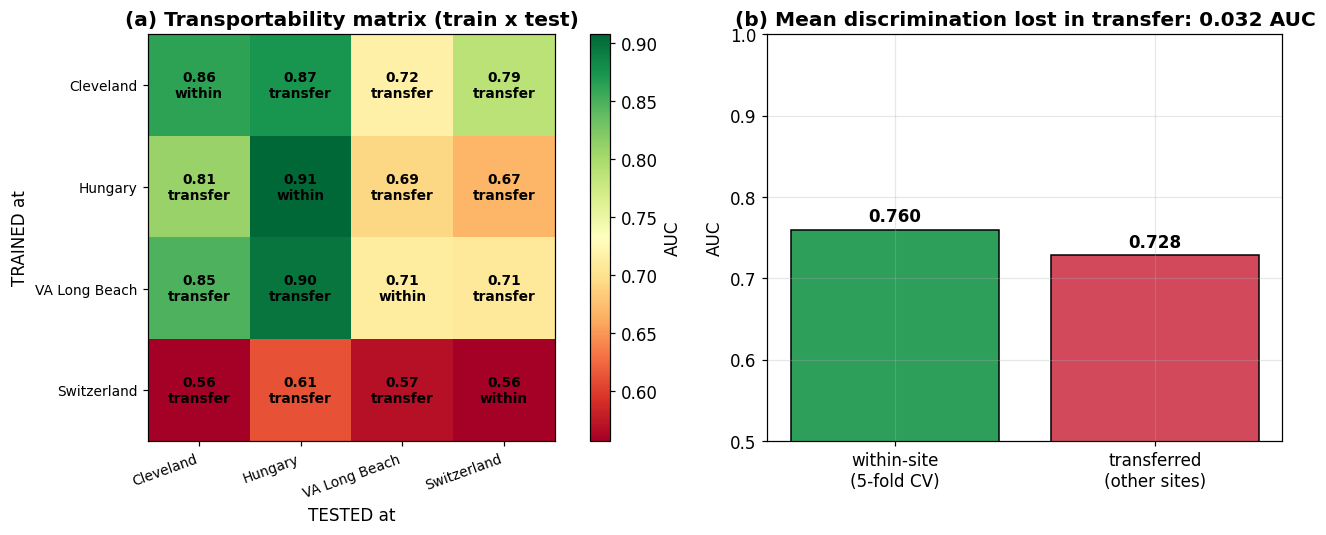

In [6]:
def cv_predict(X, y, folds=5, seed=0):
    """Out-of-fold predicted probabilities (used for both the honest diagonal AUC and calibration)."""
    rng = np.random.default_rng(seed); idx = rng.permutation(len(y)); parts = np.array_split(idx, folds)
    oof = np.full(len(y), np.nan)
    for k in range(folds):
        te = parts[k]; tr = np.concatenate([parts[m] for m in range(folds) if m != k])
        if y[tr].sum() < 3 or y[tr].sum() == len(tr):
            continue
        oof[te] = predict(logit_mle(X[tr], y[tr])[0], X[te])
    return oof

def cv_auc(X, y, folds=5, seed=0):
    """Within-site k-fold CV AUC (honest diagonal)."""
    oof = cv_predict(X, y, folds, seed); ok = ~np.isnan(oof)
    return auc(oof[ok], y[ok]) if ok.sum() > 10 else np.nan

M = np.full((K, K), np.nan)
beta_site = {}
for i, s_tr in enumerate(sites):
    tr = IDX[s_tr]
    beta_site[s_tr] = logit_mle(XALL[tr], YALL[tr])[0]
    for j, s_te in enumerate(sites):
        te = IDX[s_te]
        M[i, j] = cv_auc(XALL[te], YALL[te]) if i == j else auc(predict(beta_site[s_tr], XALL[te]), YALL[te])

MT = pd.DataFrame(M, index=[f"train:{s}" for s in sites], columns=[f"test:{s}" for s in sites])
diag = pd.Series({s: M[i, i] for i, s in enumerate(sites)}).dropna().sort_values()   # within-site skill
print(MT.round(3).to_string())
within   = np.nanmean(np.diag(M))
transfer = np.nanmean(M[~np.eye(K, dtype=bool)])
print(f"\nmean within-site AUC = {within:.3f} | mean transferred AUC = {transfer:.3f} "
      f"| drop = {within - transfer:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]; ax.grid(False)
im = ax.imshow(M, cmap="RdYlGn", vmin=np.nanmin(M), vmax=np.nanmax(M))
ax.set_xticks(range(K)); ax.set_xticklabels(sites, fontsize=9, rotation=20, ha="right")
ax.set_yticks(range(K)); ax.set_yticklabels(sites, fontsize=9)
ax.set_xlabel("TESTED at"); ax.set_ylabel("TRAINED at")
for i in range(K):
    for j in range(K):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i,j]:.2f}\n{'within' if i==j else 'transfer'}",
                    ha="center", va="center", fontsize=9, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046, label="AUC")
ax.set_title("(a) Transportability matrix (train x test)", fontweight="bold")

ax = axes[1]
ax.bar(["within-site\n(5-fold CV)", "transferred\n(other sites)"], [within, transfer],
       color=[GREEN, RED], edgecolor="k")
for k, v in enumerate([within, transfer]):
    ax.text(k, v + .01, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0.5, 1.0); ax.set_ylabel("AUC")
ax.set_title(f"(b) Mean discrimination lost in transfer: {within-transfer:.3f} AUC", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/figD1_transport.png", dpi=200, bbox_inches="tight"); plt.show()

## 3. Why the sites differ (I): prevalence = case-mix + residual site effect
Is the prevalence gap just sicker patients? Fit **one pooled risk model** on the shared features and
ask, for each site, what prevalence its patient *mix* predicts (direct standardisation). The
observed - expected difference is the residual that case-mix cannot explain.

                 n  observed  expected_casemix  residual_site
site                                                         
Cleveland      304     0.457             0.477         -0.020
Hungary        293     0.362             0.420         -0.058
VA Long Beach  200     0.745             0.774         -0.029
Switzerland    123     0.935             0.701          0.234

large case-mix component + non-zero residual => sites differ in WHO they see AND in something site-specific


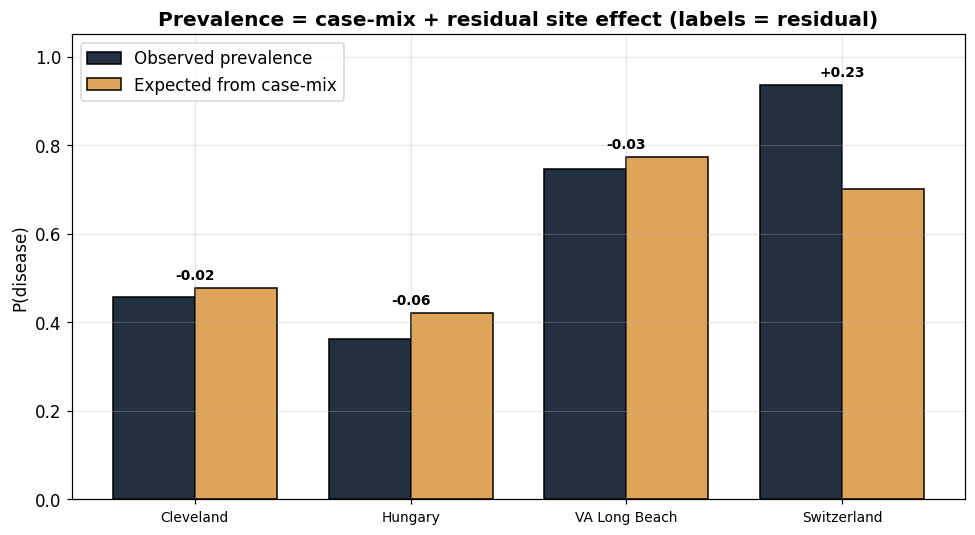

In [7]:
bpool = logit_mle(XALL, YALL)[0]
rows = []
for s in sites:
    ix = IDX[s]; exp_ = predict(bpool, XALL[ix]).mean(); obs = YALL[ix].mean()
    rows.append((s, len(ix), obs, exp_, obs - exp_))
dec = pd.DataFrame(rows, columns=["site", "n", "observed", "expected_casemix",
                                  "residual_site"]).set_index("site")
print(dec.round(3).to_string())
print("\nlarge case-mix component + non-zero residual => sites differ in WHO they see AND in something site-specific")

fig, ax = plt.subplots(figsize=(2.2 + 1.7 * K, 5)); x = np.arange(K); w = 0.38
ax.bar(x - w/2, dec.observed, w, color=NAVY,  edgecolor="k", label="Observed prevalence")
ax.bar(x + w/2, dec.expected_casemix, w, color=AMBER, edgecolor="k", label="Expected from case-mix")
for k, s in enumerate(sites):
    ax.text(k, max(dec.observed[s], dec.expected_casemix[s]) + .02,
            f"{dec.residual_site[s]:+.2f}", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(sites, fontsize=9); ax.set_ylim(0, 1.05)
ax.set_ylabel("P(disease)"); ax.legend()
ax.set_title("Prevalence = case-mix + residual site effect (labels = residual)", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/figD2_decomp.png", dpi=200, bbox_inches="tight"); plt.show()

## 4. Why the sites differ (II): each site weights the signals differently
If one diagnostic rule fitted all sites, the per-site MLEs would agree up to noise. We fit the model
separately at every site and look at the spread of each coefficient. (Small sites give unstable
estimates for rare categories - a limitation, and itself part of why transfer fails.)

In [8]:
Cf = pd.DataFrame({s: beta_site[s][1:] for s in sites}, index=FEATS)
print(Cf.round(2).to_string())
spread = (Cf.max(axis=1) - Cf.min(axis=1)).sort_values(ascending=False)
print("\nMost site-variable coefficients (max - min across sites):")
print(spread.head(6).round(2).to_string())

           Cleveland  Hungary  VA Long Beach  Switzerland
age             0.26     0.07           0.39        -0.22
sex             1.87     1.43           1.01        -8.10
restingbp       0.35    -0.03           0.08        -0.18
fbs             0.01     1.53           0.82         3.91
maxhr          -0.42    -0.05          -0.03        -0.44
exang           0.69     1.04           1.19         1.22
oldpeak         0.65     1.51           0.46         0.24
cp_ATA         -1.46    -2.51          -1.88        -2.94
cp_NAP         -2.04    -1.07          -0.59        -4.09
cp_TA          -2.37     0.47          -1.24         4.23
sl_Flat         1.16    -1.71          -0.19         4.60
sl_Up           0.36   -11.75           0.20         2.27

Most site-variable coefficients (max - min across sites):
sl_Up      14.02
sex         9.97
cp_TA       6.60
sl_Flat     6.31
fbs         3.90
cp_NAP      3.50


## 4b. Formal likelihood test of between-site heterogeneity
Comparing bars is only suggestive. The proper question - *does a single diagnostic rule fit all
sites?* - is a **nested-model** problem, so we use the **generalized likelihood-ratio test**
(GLRT), with **Wald** intervals to localise the divergences. With \(K\) sites we use \(K-1\)
site dummies (reference = the largest site):

- **M0**: features only (one common rule);
- **M1**: features + site  ->  GLRT(M0,M1), \(df = K-1\), tests a **residual site effect** (intercept
  shift beyond case-mix): the formal version of SS3;
- **M2**: M1 + site x feature interactions  ->  GLRT(M1,M2), \(df = (K-1)p\), tests **coefficient
  heterogeneity**: the formal statement that transportability *must* fail.

Under \(H_0\), \(2\log\Lambda \sim \chi^2_{df}\) (Wilks). Typical-angina is dropped from the
interaction block because it is quasi-separated at the small sites.

The omnibus M2 test spends \((K-1)p\) degrees of freedom at once, which makes it blunt; we therefore
also run a **per-feature** GLRT (M1 vs M1 + one feature x site, \(df = K-1\)) to localise the
heterogeneity, and control the resulting multiplicity with **Bonferroni** over the \(p\) features.

In [9]:
S = np.column_stack([(df.site.values == s).astype(float) for s in sites[1:]])   # K-1 dummies
INT_FEATS = [f for f in FEATS if f != "cp_TA"]                                  # stable interaction set
Xi = XDF[INT_FEATS].values.astype(float)
INTER = np.column_stack([Xi * S[:, [k]] for k in range(S.shape[1])])            # (K-1)*p columns

X0 = XALL
X1 = np.column_stack([X0, S])
X2 = np.column_stack([X1, INTER])
b0, _,   ll0 = logit_mle(X0, YALL)
b1, se1, ll1 = logit_mle(X1, YALL)
b2, se2, ll2 = logit_mle(X2, YALL)

df1, df2 = S.shape[1], INTER.shape[1]
LR1, LR2 = 2 * (ll1 - ll0), 2 * (ll2 - ll1)
p1, p2   = stats.chi2.sf(LR1, df1), stats.chi2.sf(LR2, df2)
print(f"GLRT(M0,M1) residual site effect      : LR = {LR1:8.2f}, df = {df1:2d}, p = {p1:.2e}")
print(f"GLRT(M1,M2) coefficient heterogeneity : LR = {LR2:8.2f}, df = {df2:2d}, p = {p2:.2e}")
print("  -> " + ("a single diagnostic rule does NOT fit all sites: transportability must fail."
                 if p2 < 0.05 else
                 "no significant coefficient heterogeneity at alpha=0.05 (H0 of a common rule is not rejected)."))
print("  -> " + ("sites also differ in baseline risk beyond case-mix (residual site effect)."
                 if p1 < 0.05 else "no residual site effect beyond case-mix.") + "\n")

print(f"Wald site main effects (reference = {sites[0]}):")
for k, s in enumerate(sites[1:]):
    b, se = b1[1 + len(FEATS) + k], se1[1 + len(FEATS) + k]
    flag = "   [quasi-separated: unstable]" if (se > 3 or abs(b) > 8) else ""
    print(f"   {s:16s} OR = {np.exp(b):8.2f}  95% CI [{np.exp(b-1.96*se):.2f}, {np.exp(b+1.96*se):.2f}]"
          f"   two-sided p = {2*stats.norm.sf(abs(b/se)):.2e}   one-sided p = {stats.norm.sf(b/se):.2e}{flag}")

ib, ise = b2[-df2:], se2[-df2:]
names = [f"{f} x {s}" for s in sites[1:] for f in INT_FEATS]
wald = pd.DataFrame({"beta": ib, "se": ise,
                     "z": ib / ise, "p": 2 * stats.norm.sf(np.abs(ib / ise))}, index=names)
print("\nStrongest site x feature interactions (Wald):")
print(wald.sort_values("p").head(6).round(3).to_string())

# Per-feature heterogeneity GLRTs: M1 vs M1 + (one feature) x site, df = K-1 each.
# The omnibus test above spends (K-1)p degrees of freedom at once, so it is blunt; testing one
# feature at a time is far better powered, at the price of multiplicity -> Bonferroni over p tests.
rows = []
for f in INT_FEATS:
    xf = XDF[f].values.astype(float)[:, None] * S
    llf = logit_mle(np.column_stack([X1, xf]), YALL)[2]
    lr = 2 * (llf - ll1)
    rows.append((f, lr, df1, stats.chi2.sf(lr, df1)))
per = pd.DataFrame(rows, columns=["feature", "LR", "df", "p"]).set_index("feature")
per["p_bonferroni"] = np.minimum(per.p * len(per), 1)
per["reject_0.05"] = per.p_bonferroni < 0.05
print(f"\nPer-feature heterogeneity GLRTs (M1 vs M1 + feature x site, df = {df1}), Bonferroni m = {len(per)}:")
print(per.sort_values("p").round(4).to_string())

GLRT(M0,M1) residual site effect      : LR =    75.02, df =  3, p = 3.58e-16
GLRT(M1,M2) coefficient heterogeneity : LR =    53.95, df = 33, p = 1.21e-02
  -> a single diagnostic rule does NOT fit all sites: transportability must fail.
  -> sites also differ in baseline risk beyond case-mix (residual site effect).

Wald site main effects (reference = Cleveland):
   Hungary          OR =     0.64  95% CI [0.36, 1.12]   two-sided p = 1.19e-01   one-sided p = 9.41e-01
   VA Long Beach    OR =     0.96  95% CI [0.54, 1.72]   two-sided p = 9.01e-01   one-sided p = 5.50e-01
   Switzerland      OR =    15.95  95% CI [6.49, 39.21]   two-sided p = 1.59e-09   one-sided p = 7.95e-10

Strongest site x feature interactions (Wald):
                         beta     se      z      p
oldpeak x Hungary       0.897  0.390  2.302  0.021
cp_NAP x VA Long Beach  1.211  0.574  2.109  0.035
cp_ATA x Hungary       -1.397  0.725 -1.925  0.054
fbs x Hungary           1.563  0.903  1.732  0.083
sl_Flat x Switzer

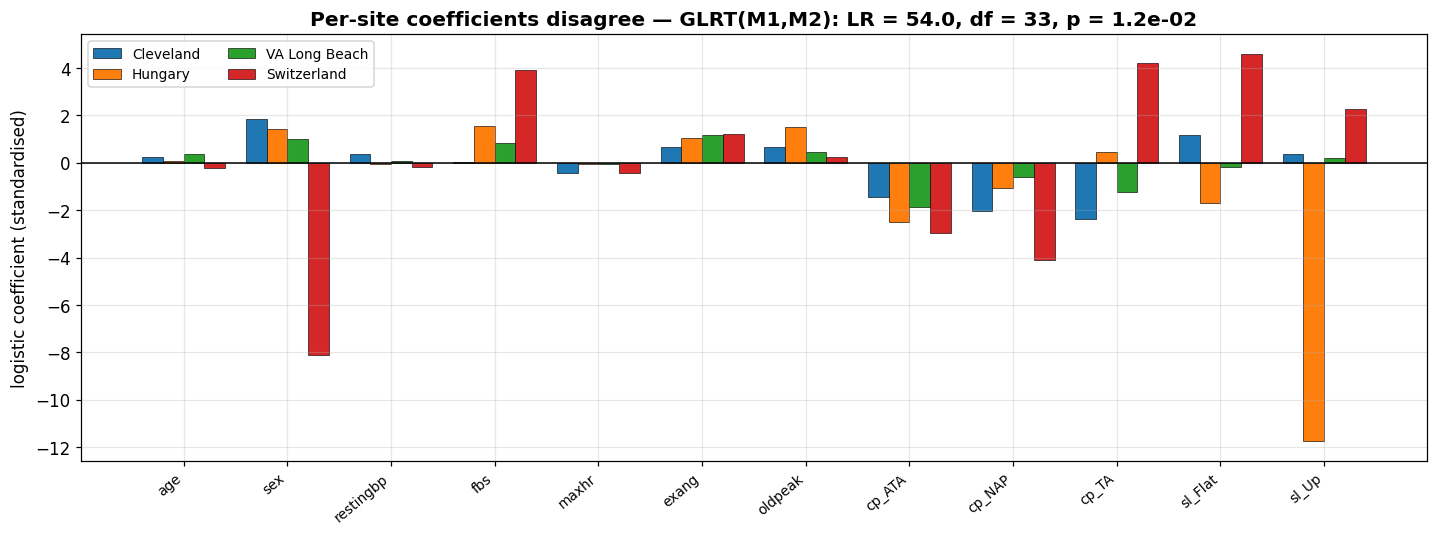

In [10]:
fig, ax = plt.subplots(figsize=(max(9, 1.1 * len(FEATS)), 5))
x = np.arange(len(FEATS)); w = 0.8 / K
for k, s in enumerate(sites):
    ax.bar(x + (k - (K - 1) / 2) * w, Cf[s].values, w, edgecolor="k", linewidth=.4, label=s)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels(FEATS, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("logistic coefficient (standardised)"); ax.legend(fontsize=9, ncol=2)
ax.set_title(f"Per-site coefficients disagree — GLRT(M1,M2): LR = {LR2:.1f}, df = {df2}, p = {p2:.1e}",
             fontweight="bold")
plt.tight_layout(); plt.savefig("figures/figD3_coefs.png", dpi=200, bbox_inches="tight"); plt.show()

### Breslow-Day / Cochran-Mantel-Haenszel
The GLRT is a global statement. For a single binary predictor we can ask the classical stratified
question directly: is its odds ratio **common** across sites (Breslow-Day homogeneity), and what is
the pooled CMH estimate?

In [11]:
def cmh_breslow_day(d, exposure, outcome="target", strat="site"):
    num = den = a_sum = Ea = Va = 0.0; tabs = []
    for _, g in d.groupby(strat):
        a = int(((g[exposure] == 1) & (g[outcome] == 1)).sum()); b = int(((g[exposure] == 1) & (g[outcome] == 0)).sum())
        c = int(((g[exposure] == 0) & (g[outcome] == 1)).sum()); e = int(((g[exposure] == 0) & (g[outcome] == 0)).sum())
        n = a + b + c + e
        if min(a + b, c + e, a + c, b + e) == 0:   # degenerate stratum
            continue
        num += a * e / n; den += b * c / n; a_sum += a
        Ea += (a + b) * (a + c) / n
        Va += (a + b) * (c + e) * (a + c) * (b + e) / (n ** 2 * (n - 1))
        tabs.append((a, b, c, e, n))
    if den == 0 or len(tabs) < 2:
        return None
    OR = num / den
    chi_cmh = (abs(a_sum - Ea) - 0.5) ** 2 / Va                       # continuity-corrected CMH
    bd = 0.0
    for (a, b, c, e, n) in tabs:                                      # Breslow-Day homogeneity
        A, B, Cc = OR - 1, -(OR * ((a + b) + (a + c)) + (n - (a + b) - (a + c))), OR * (a + b) * (a + c)
        if abs(A) < 1e-9:
            Ek = Cc / -B
        else:
            disc = max(B * B - 4 * A * Cc, 0); Ek = (-B - np.sqrt(disc)) / (2 * A)
            if not (0 < Ek < min(a + b, a + c)):
                Ek = (-B + np.sqrt(disc)) / (2 * A)
        Vk = 1 / (1 / Ek + 1 / ((a + b) - Ek) + 1 / ((a + c) - Ek) + 1 / (n - (a + b) - (a + c) + Ek))
        bd += (a - Ek) ** 2 / Vk
    return OR, stats.chi2.sf(chi_cmh, 1), stats.chi2.sf(bd, len(tabs) - 1), len(tabs)

print("Does a single predictor's odds ratio travel across sites?")
for exp_ in ["exang", "fbs", "sex"]:
    r = cmh_breslow_day(df, exp_)
    if r:
        print(f"   {exp_:6s}: CMH OR = {r[0]:5.2f} (p = {r[1]:.1e}) | Breslow-Day p = {r[2]:.3f} "
              f"-> {'HETEROGENEOUS' if r[2] < 0.05 else 'homogeneous'} across {r[3]} sites")

Does a single predictor's odds ratio travel across sites?
   exang : CMH OR =  8.20 (p = 4.7e-37) | Breslow-Day p = 0.025 -> HETEROGENEOUS across 4 sites
   fbs   : CMH OR =  1.61 (p = 3.0e-02) | Breslow-Day p = 0.246 -> homogeneous across 4 sites
   sex   : CMH OR =  3.71 (p = 5.1e-11) | Breslow-Day p = 0.366 -> homogeneous across 4 sites


## 4c. Uncertainty on the transfer: bootstrap + DeLong, and the power of the GLRT
Three refinements a theory reader expects.
**(i) Bootstrap CIs** for the transferred AUCs (resampling the test site, 2000 replicates).
**(ii) DeLong** analytic AUC variance as an independent check on the same quantities, plus a
two-sample DeLong test of whether two sites differ in *within-site predictability* (i.e. diagnostic
difficulty, not transfer).
**(iii) Power**: under the alternative the GLRT statistic is approximately non-central
\(\chi^2_{df}(\lambda)\); using the observed statistic as \(\hat\lambda\) gives post-hoc power, and
inverting gives the \(\lambda\) required for 80% power.

In [12]:
def delong_auc_var(scores, labels):
    """AUC and its DeLong variance (Sun-Xu midrank form)."""
    scores = np.asarray(scores, float); labels = np.asarray(labels, float)
    pos, neg = scores[labels == 1], scores[labels == 0]; m, n = len(pos), len(neg)
    if m < 2 or n < 2:                      # AUC undefined / variance not estimable
        return np.nan, np.nan
    def midrank(x):
        order = np.argsort(x); xs = x[order]; N = len(x); r = np.zeros(N); i = 0
        while i < N:
            j = i
            while j < N and xs[j] == xs[i]:
                j += 1
            r[i:j] = 0.5 * (i + j - 1) + 1; i = j
        out = np.empty(N); out[order] = r; return out
    tz = midrank(np.concatenate([pos, neg])); tx = midrank(pos); ty = midrank(neg)
    A   = (tz[:m].sum() / m - (m + 1) / 2.0) / n
    v01 = (tz[:m] - tx) / n; v10 = 1.0 - (tz[m:] - ty) / m
    return A, np.var(v01, ddof=1) / m + np.var(v10, ddof=1) / n

REF = sites[0]                                    # transfer FROM the largest site
rng = np.random.default_rng(1)
rows = []
for s in sites[1:]:
    te = IDX[s]; sc = predict(beta_site[REF], XALL[te]); y = YALL[te]
    if min(y.sum(), len(y) - y.sum()) < 2:
        print(f"   (skipping {s}: only one outcome class present, AUC undefined)")
        continue
    a_hat, v = delong_auc_var(sc, y); se = np.sqrt(v)
    boot = np.array([auc(sc[i], y[i]) for i in
                     (rng.integers(0, len(y), len(y)) for _ in range(2000))])
    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    rows.append((f"{REF} -> {s}", a_hat, lo, hi, a_hat - 1.96 * se, a_hat + 1.96 * se))
tr = pd.DataFrame(rows, columns=["transfer", "AUC", "boot_lo", "boot_hi",
                                 "delong_lo", "delong_hi"]).set_index("transfer")
print(f"Transferred AUCs from the {REF} model (2000 bootstrap replicates vs analytic DeLong):")
print(tr.round(3).to_string())
print("\nIf the two interval methods agree, the transferred AUC (and the drop from the diagonal)"
      "\nis a real effect rather than a resampling artefact.")

# two-sample DeLong: do the easiest and hardest sites really differ in within-site predictability?
if len(diag) >= 2:
    s_hard, s_easy = diag.index[0], diag.index[-1]
    a1, v1 = delong_auc_var(predict(beta_site[s_easy], XALL[IDX[s_easy]]), YALL[IDX[s_easy]])
    a2, v2 = delong_auc_var(predict(beta_site[s_hard], XALL[IDX[s_hard]]), YALL[IDX[s_hard]])
    d_, sed = a1 - a2, np.sqrt(v1 + v2); z = d_ / sed
    print(f"\nWithin-site (apparent) AUC difference {s_easy} - {s_hard} = {d_:+.3f} "
          f"95% CI [{d_-1.96*sed:.3f}, {d_+1.96*sed:.3f}], p = {2*stats.norm.sf(abs(z)):.3f}")

Transferred AUCs from the Cleveland model (2000 bootstrap replicates vs analytic DeLong):
                              AUC  boot_lo  boot_hi  delong_lo  delong_hi
transfer                                                                 
Cleveland -> Hungary        0.874    0.828    0.918      0.830      0.919
Cleveland -> VA Long Beach  0.717    0.637    0.794      0.638      0.796
Cleveland -> Switzerland    0.788    0.644    0.916      0.647      0.930

If the two interval methods agree, the transferred AUC (and the drop from the diagonal)
is a real effect rather than a resampling artefact.

Within-site (apparent) AUC difference Hungary - Switzerland = -0.021 95% CI [-0.079, 0.038], p = 0.489


In [13]:
from scipy.optimize import brentq
crit  = stats.chi2.ppf(0.95, df2)
power = stats.ncx2.sf(crit, df2, LR2)                       # post-hoc power at lambda_hat = LR2
lam80 = brentq(lambda L: stats.ncx2.sf(crit, df2, L) - 0.80, 1, 10 * max(LR2, df2) + 200)
print(f"Heterogeneity GLRT: LR = {LR2:.1f}, df = {df2}, critical value = {crit:.1f}")
print(f"  post-hoc power at lambda_hat = LR  : {power:.3f}  ({'well powered' if power > .8 else 'UNDERpowered'})")
print(f"  non-centrality needed for 80% power: {lam80:.1f}")
print(f"  Type-II error at the observed effect: beta = {1-power:.3f}")

Heterogeneity GLRT: LR = 54.0, df = 33, critical value = 47.4
  post-hoc power at lambda_hat = LR  : 0.997  (well powered)
  non-centrality needed for 80% power: 25.5
  Type-II error at the observed effect: beta = 0.003


## 4e. Beyond ranking: does *calibration* transport?
AUC only measures **ranking** - whether sick patients get higher scores than healthy ones. A model can
rank perfectly and still output probabilities that are badly wrong, which is what actually matters if
a clinician reads "72% risk". We therefore evaluate the second half of the learning-evaluation
toolkit at every site, comparing a **within-site** model (out-of-fold CV predictions) with the
**transported** model:

* **calibration-in-the-large** = mean predicted risk minus observed prevalence (0 if unbiased);
* **calibration slope and intercept** from the recalibration regression
  \(\operatorname{logit}P(Y=1)=a+b\cdot\operatorname{logit}\hat p\); perfect calibration is \(a=0,b=1\),
  and \(b<1\) is the classic sign of over-fitted, too-extreme probabilities;
* **Brier score** \(\frac1n\sum(\hat p_i-y_i)^2\), a proper scoring rule combining calibration and
  discrimination;
* the **Hosmer-Lemeshow** goodness-of-fit test, a \(\chi^2\) statistic on \(g\) risk deciles with
  \(g-2\) degrees of freedom (small \(p\) = the fitted risks do not match the observed frequencies).

In [14]:
def calibration_report(p, y, g=5):
    """Calibration-in-the-large, recalibration slope/intercept, Brier score, Hosmer-Lemeshow."""
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6); y = np.asarray(y, float)
    b, se, _ = logit_mle(logit(p).reshape(-1, 1), y)            # a + b*logit(p)
    z_slope = (b[1] - 1) / se[1]                                 # H0: slope = 1
    HL, used = 0.0, 0
    grp = pd.qcut(p, g, labels=False, duplicates="drop")
    for k in np.unique(grp):
        m = grp == k; n = int(m.sum()); o = y[m].sum(); e = p[m].sum()
        if n < 2 or e <= 0 or e >= n:
            continue
        HL += (o - e) ** 2 / (e * (1 - e / n)); used += 1
    df_hl = max(used - 2, 1)
    return {"mean_pred": p.mean(), "observed": y.mean(), "CIL": p.mean() - y.mean(),
            "intercept": b[0], "slope": b[1], "slope_p": 2 * stats.norm.sf(abs(z_slope)),
            "Brier": float(np.mean((p - y) ** 2)),
            "HL": HL, "HL_df": df_hl, "HL_p": stats.chi2.sf(HL, df_hl)}

REF = sites[0]
rows = []
for s in sites:
    ix = IDX[s]; y = YALL[ix]
    oof = cv_predict(XALL[ix], y); ok = ~np.isnan(oof)
    if ok.sum() > 20:
        rows.append(dict(site=s, model="within-site (CV)", **calibration_report(oof[ok], y[ok])))
    if s != REF:
        rows.append(dict(site=s, model=f"transported from {REF}",
                         **calibration_report(predict(beta_site[REF], XALL[ix]), y)))
cal = pd.DataFrame(rows).set_index(["site", "model"])
print(cal[["observed", "mean_pred", "CIL", "intercept", "slope", "Brier", "HL", "HL_df", "HL_p"]].round(3).to_string())
print("\nperfect calibration: CIL = 0, intercept = 0, slope = 1, large Hosmer-Lemeshow p")
print("slope < 1 => transported probabilities are too extreme; CIL > 0 => risk systematically over-stated")

                                          observed  mean_pred    CIL  intercept  slope  Brier          HL  HL_df   HL_p
site          model                                                                                                    
Cleveland     within-site (CV)               0.457      0.460  0.003     -0.055  0.791  0.150       7.425      3  0.060
Hungary       within-site (CV)               0.362      0.357 -0.004     -0.026  0.859  0.113       4.795      3  0.187
              transported from Cleveland     0.362      0.484  0.122     -0.889  0.918  0.153      41.563      3  0.000
VA Long Beach within-site (CV)               0.745      0.745 -0.000      0.355  0.607  0.172       9.955      3  0.019
              transported from Cleveland     0.745      0.785  0.040      0.193  0.577  0.177      16.817      3  0.001
Switzerland   within-site (CV)               0.935      0.913 -0.022      2.502  0.022  0.096  274269.396      2  0.000
              transported from Cleveland

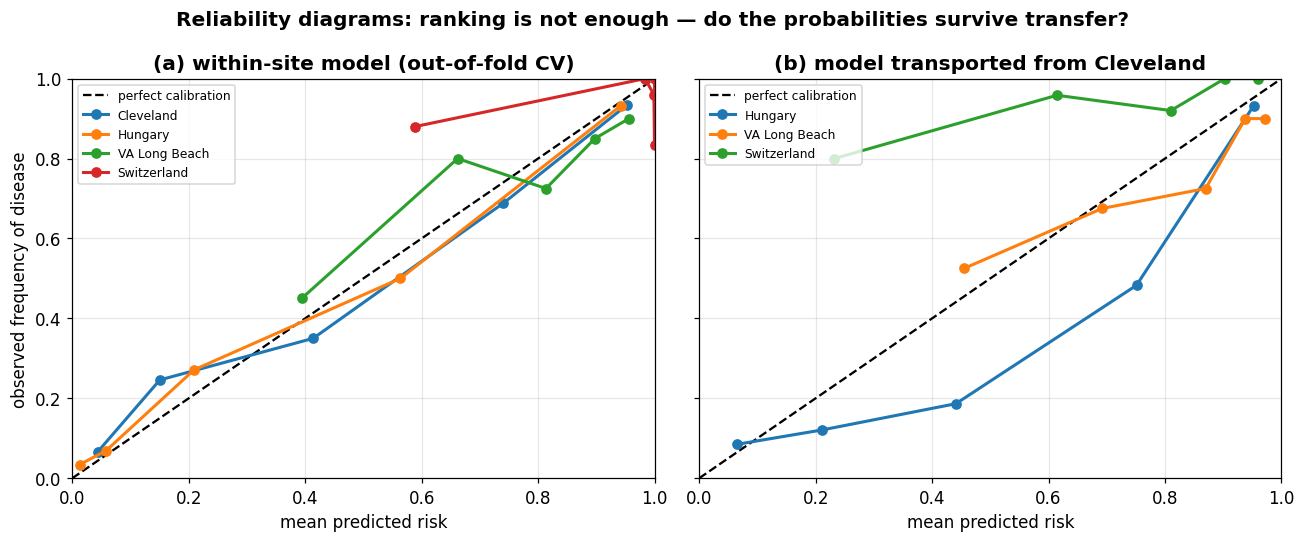

In [15]:
def reliability(p, y, g=5):
    """Mean predicted vs observed frequency inside g equal-count risk bins."""
    p = np.asarray(p, float); grp = pd.qcut(p, g, labels=False, duplicates="drop")
    return np.array([[p[grp == k].mean(), y[grp == k].mean()] for k in np.unique(grp)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, mode in zip(axes, ["within", "transported"]):
    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="perfect calibration")
    for s in sites:
        ix = IDX[s]; y = YALL[ix]
        if mode == "within":
            pp = cv_predict(XALL[ix], y); ok = ~np.isnan(pp)
            if ok.sum() < 20:
                continue
            pts = reliability(pp[ok], y[ok])
        else:
            if s == REF:
                continue
            pts = reliability(predict(beta_site[REF], XALL[ix]), y)
        ax.plot(pts[:, 0], pts[:, 1], "o-", lw=2, ms=6, label=s)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel("mean predicted risk")
    ax.set_title(("(a) within-site model (out-of-fold CV)" if mode == "within"
                  else f"(b) model transported from {REF}"), fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("observed frequency of disease")
plt.suptitle("Reliability diagrams: ranking is not enough — do the probabilities survive transfer?",
             fontweight="bold")
plt.tight_layout(); plt.savefig("figures/figD5_calibration.png", dpi=200, bbox_inches="tight"); plt.show()

## 4d. Simulation study: does the test behave as theory predicts?
A method is trustworthy only if it recovers known truth. We simulate \(K\) sites with **our** sample
sizes, sharing one logistic model except for a controlled coefficient shift \(\delta\) on one feature
at the non-reference sites, and record how often the site x feature GLRT rejects "one common rule".
At \(\delta=0\) the rejection rate should equal the nominal \(\alpha=0.05\) (Type-I control); as
\(\delta\) grows it is the **power** curve.

  delta = 0.00: rejection rate = 0.060   (Type-I error)
  delta = 0.25: rejection rate = 0.145   (power)
  delta = 0.50: rejection rate = 0.390   (power)
  delta = 0.75: rejection rate = 0.690   (power)
  delta = 1.00: rejection rate = 0.905   (power)
  delta = 1.50: rejection rate = 1.000   (power)


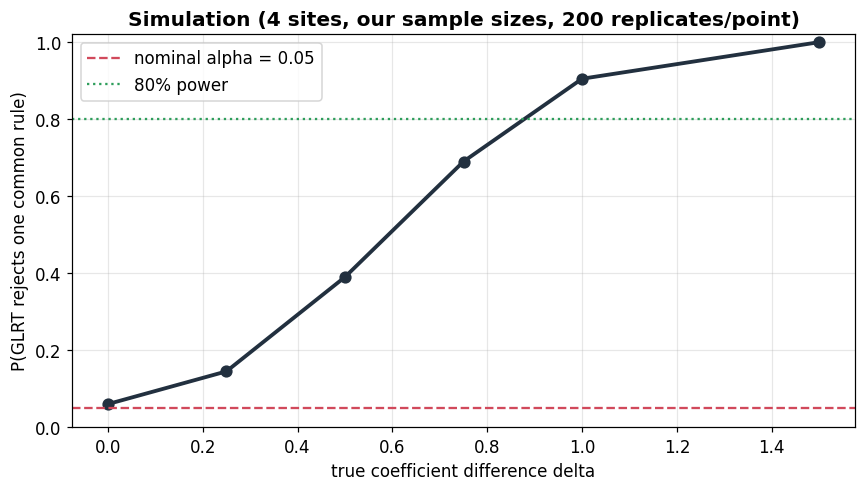

In [16]:
def sim_reject(delta, ns, p=5, alpha=0.05, rng=None):
    """One synthetic replicate: K sites, identical model except a shift delta at the non-reference sites."""
    rng = rng or np.random.default_rng()
    beta = np.array([0.0, 0.8, -0.6, 0.5, 0.4, -0.7])[:p + 1]
    Xs, ys, ss = [], [], []
    for k, n in enumerate(ns):
        b = beta.copy()
        if k > 0:
            b[1] += delta
        Xk = rng.normal(size=(n, p))
        pk = 1 / (1 + np.exp(-(b[0] + Xk @ b[1:])))
        Xs.append(Xk); ys.append((rng.random(n) < pk).astype(float)); ss.append(np.full(n, k))
    X = np.vstack(Xs); y = np.concatenate(ys); site = np.concatenate(ss)
    D = np.column_stack([(site == k).astype(float) for k in range(1, len(ns))])
    XM1 = np.column_stack([X, D])
    XM2 = np.column_stack([XM1] + [X * D[:, [k]] for k in range(D.shape[1])])
    ll1 = logit_mle(XM1, y)[2]                     # <- unpack the log-likelihood (index 2)
    ll2 = logit_mle(XM2, y)[2]
    return stats.chi2.sf(2 * (ll2 - ll1), D.shape[1] * X.shape[1]) < alpha

ns_sim = [len(IDX[s]) for s in sites]
deltas = [0, 0.25, 0.5, 0.75, 1.0, 1.5]
R = 200                                            # replicates per delta (raise for smoother curves)
rng_sim = np.random.default_rng(7)
powers = [np.mean([sim_reject(d, ns_sim, rng=rng_sim) for _ in range(R)]) for d in deltas]
for d, pw in zip(deltas, powers):
    print(f"  delta = {d:.2f}: rejection rate = {pw:.3f}   ({'Type-I error' if d == 0 else 'power'})")

plt.figure(figsize=(8, 4.6))
plt.plot(deltas, powers, "o-", color=NAVY, lw=2.5, ms=7)
plt.axhline(0.05, color=RED, ls="--", label="nominal alpha = 0.05")
plt.axhline(0.80, color=GREEN, ls=":", label="80% power")
plt.xlabel("true coefficient difference delta"); plt.ylabel("P(GLRT rejects one common rule)")
plt.ylim(0, 1.02); plt.legend()
plt.title(f"Simulation ({K} sites, our sample sizes, {R} replicates/point)", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/figD4_sim.png", dpi=200, bbox_inches="tight"); plt.show()

## 5. Why the sites differ (III): different usable variables and symptom mixes
Two concrete mechanisms behind the failed transfer, both properties of the *site* rather than of
biology: **(a)** cholesterol (and the ST-slope) are simply not recorded at some hospitals, so a model
that leans on them cannot be applied there; **(b)** the chest-pain mix differs by site, so the
*meaning* of "asymptomatic" is not portable — the same label carries a different disease risk.

In [17]:
audit = pd.DataFrame({
    "chol never measured": 1 - df.groupby("site").chol_measured.mean(),
    "restingBP missing":   df.groupby("site").bp_missing.mean(),
    "slope missing (raw)": df_raw.groupby("site").slope.apply(lambda s: s.isna().mean())}).loc[sites]
print("Fraction unusable/imputed by site:"); print(audit.round(3).to_string())

mix = pd.crosstab(df.site, df.cp, normalize="index").loc[sites]
print("\nChest-pain mix by site:"); print(mix.round(2).to_string())

asy = df[df.cp == "ASY"].groupby("site").target.agg(["size", "mean"]).loc[
        [s for s in sites if s in df[df.cp == "ASY"].site.unique()]]
print("\nP(disease | asymptomatic) by site:"); print(asy.rename(columns={"size": "n", "mean": "P(disease)"}).round(3).to_string())
chi2, pchi, dof, _ = stats.chi2_contingency(pd.crosstab(df.site, df.cp))
print(f"\nChi-square test of independence (site x chest-pain): chi2 = {chi2:.1f}, df = {dof}, p = {pchi:.2e}")

Fraction unusable/imputed by site:
               chol never measured  restingBP missing  slope missing (raw)
site                                                                      
Cleveland                    0.000              0.000                0.003
Hungary                      0.078              0.003                0.645
VA Long Beach                0.280              0.285                0.510
Switzerland                  1.000              0.016                0.138

Chest-pain mix by site:
cp              ASY   ATA   NAP    TA
site                                 
Cleveland      0.47  0.17  0.28  0.08
Hungary        0.42  0.36  0.18  0.04
VA Long Beach  0.66  0.07  0.24  0.04
Switzerland    0.80  0.03  0.14  0.03

P(disease | asymptomatic) by site:
                 n  P(disease)
site                          
Cleveland      144       0.729
Hungary        123       0.675
VA Long Beach  131       0.824
Switzerland     98       0.980

Chi-square test of independence (site x

## 6. Diagnostic difficulty — where is disease hardest to predict?
"Which hospital is better?" is unanswerable without external ground truth. The answerable version is
*where is disease hardest to predict from the recorded features?* — the within-site CV AUC, i.e. the
diagonal of the transportability matrix.

In [18]:
print("Within-site cross-validated AUC (higher = easier to predict):")
print(diag.round(3).to_string())
skipped = [s for s in sites if s not in diag.index]
if skipped:
    print("(no CV AUC for: " + ", ".join(skipped) + " -- too few patients in one outcome class)")
if len(diag) >= 2:
    print(f"\nhardest: {diag.index[0]} ({diag.iloc[0]:.3f}) | easiest: {diag.index[-1]} ({diag.iloc[-1]:.3f})")
print("Difficulty reflects recorded-feature quality, prevalence and sample size — not clinician skill.")

Within-site cross-validated AUC (higher = easier to predict):
Switzerland      0.558
VA Long Beach    0.711
Cleveland        0.864
Hungary          0.908

hardest: Switzerland (0.558) | easiest: Hungary (0.908)
Difficulty reflects recorded-feature quality, prevalence and sample size — not clinician skill.


## Appendix A — classical distribution theory and multiplicity
**A.1 Two-part (hurdle) MLE for ST-depression (`oldpeak`).** `oldpeak` is zero-inflated (a large exact
spike at 0) with a skewed positive tail, so no single density fits it. We model
\(P(Y=0)=\pi\) (Bernoulli) plus a Gamma on \(Y>0\) fitted by **maximum likelihood via Nelder-Mead**,
assessed with the **Kolmogorov-Smirnov** statistic \(D_n=\sup_x|F_n(x)-F(x)|\).
**A.2 Multiplicity.** The primary family of association tests is corrected by **Bonferroni**.

In [19]:
from scipy import optimize

op = df.oldpeak.values.astype(float)
pos = op[op > 0]
pi0 = float((op == 0).mean())
shift = op - op.min() + 1e-6
a1, l1, s1 = stats.gamma.fit(shift)
D_naive = stats.kstest(shift, "gamma", args=(a1, l1, s1)).statistic
negll = lambda th, x: 1e12 if (th[0] <= 0 or th[1] <= 0) else -np.sum(stats.gamma.logpdf(x, th[0], scale=th[1]))
k_, th_ = optimize.minimize(negll, [1.5, 1.0], args=(pos,), method="Nelder-Mead").x
D_two = stats.kstest(pos, "gamma", args=(k_, 0, th_)).statistic
print(f"A.1  zero spike pi0 = {pi0:.2f}")
print(f"     single Gamma on shifted data : KS D = {D_naive:.3f}")
print(f"     two-part Gamma (Nelder-Mead) : k = {k_:.2f}, theta = {th_:.2f}, KS D = {D_two:.3f}")

fam = {
 "MaxHR (Welch t)":      stats.ttest_ind(df[df.target == 0].maxhr, df[df.target == 1].maxhr, equal_var=False).pvalue,
 "Oldpeak (Mann-Whitney)": stats.mannwhitneyu(df[df.target == 0].oldpeak, df[df.target == 1].oldpeak).pvalue,
 "ChestPain (chi-square)":  stats.chi2_contingency(pd.crosstab(df.cp, df.target)).pvalue,
 "CholMissing (chi-square)": stats.chi2_contingency(pd.crosstab(df.chol_measured, df.target)).pvalue,
 "FastingBS (chi-square)":  stats.chi2_contingency(pd.crosstab(df.fbs, df.target)).pvalue}
m = len(fam)
print(f"\nA.2  Bonferroni correction, m = {m}:")
for name, p in fam.items():
    print(f"     {name:26s} p = {p:.2e}   Bonferroni = {min(p*m,1):.2e}   {'significant' if p*m < 0.05 else 'ns'}")

A.1  zero spike pi0 = 0.40
     single Gamma on shifted data : KS D = 0.225
     two-part Gamma (Nelder-Mead) : k = 2.65, theta = 0.60, KS D = 0.129

A.2  Bonferroni correction, m = 5:
     MaxHR (Welch t)            p = 1.02e-33   Bonferroni = 5.10e-33   significant
     Oldpeak (Mann-Whitney)     p = 6.94e-32   Bonferroni = 3.47e-31   significant
     ChestPain (chi-square)     p = 7.04e-58   Bonferroni = 3.52e-57   significant
     CholMissing (chi-square)   p = 4.34e-16   Bonferroni = 2.17e-15   significant
     FastingBS (chi-square)     p = 1.45e-03   Bonferroni = 7.24e-03   significant


## Summary — the numbers to paste into the report

In [20]:
print("=" * 74)
print("KEY NUMBERS  (paste these into the LaTeX report)".center(74))
print("=" * 74)
print(f"sites (n)                  : " + ", ".join(f"{s} {len(IDX[s])}" for s in sites))
print(f"prevalence by site         : " + ", ".join(f"{s} {prev.prevalence[s]:.1%}" for s in sites))
print(f"within-site CV AUC (mean)  : {within:.3f}   " + ", ".join(f"{s} {M[i,i]:.2f}" for i, s in enumerate(sites) if not np.isnan(M[i, i])))
print(f"transferred AUC (mean)     : {transfer:.3f}   -> drop = {within-transfer:.3f}")
print(f"largest residual site eff. : {dec.residual_site.abs().idxmax()} "
      f"{dec.residual_site[dec.residual_site.abs().idxmax()]:+.3f}")
print(f"GLRT(M0,M1) site effect    : LR = {LR1:.1f}, df = {df1}, p = {p1:.2e}")
print(f"GLRT(M1,M2) heterogeneity  : LR = {LR2:.1f}, df = {df2}, p = {p2:.2e}, power = {power:.3f}")
print(f"top interaction            : {wald.p.idxmin()} (beta = {wald.beta[wald.p.idxmin()]:+.2f}, p = {wald.p.min():.3f})")
_pf = per.sort_values("p").iloc[0]
print(f"best per-feature GLRT      : {per.p.idxmin()} LR = {_pf.LR:.1f}, df = {int(_pf.df)}, "
      f"p = {_pf.p:.2e}, Bonferroni p = {_pf.p_bonferroni:.2e} "
      f"({int(per['reject_0.05'].sum())}/{len(per)} features survive correction)")
print(f"simulated Type-I at delta=0: {powers[0]:.3f}   (nominal 0.05)")
print(f"KS oldpeak                 : single {D_naive:.3f} -> two-part {D_two:.3f}")
_w = cal.xs("within-site (CV)", level="model"); _t = cal[cal.index.get_level_values(1).str.startswith("transported")]
print(f"calibration slope (within) : " + ", ".join(f"{i} {v:.2f}" for i, v in _w.slope.items()))
print(f"calibration slope (transf.): " + ", ".join(f"{i[0]} {v:.2f}" for i, v in _t.slope.items()))
print(f"Brier within / transported : {_w.Brier.mean():.3f} / {_t.Brier.mean():.3f}")
print(f"Hosmer-Lemeshow p (transf.): " + ", ".join(f"{i[0]} {v:.3f}" for i, v in _t.HL_p.items()))
print("=" * 74)
print("figures written to figures/: figD1_transport, figD2_decomp, figD3_coefs, figD4_sim, figD5_calibration")

             KEY NUMBERS  (paste these into the LaTeX report)             
sites (n)                  : Cleveland 304, Hungary 293, VA Long Beach 200, Switzerland 123
prevalence by site         : Cleveland 45.7%, Hungary 36.2%, VA Long Beach 74.5%, Switzerland 93.5%
within-site CV AUC (mean)  : 0.760   Cleveland 0.86, Hungary 0.91, VA Long Beach 0.71, Switzerland 0.56
transferred AUC (mean)     : 0.728   -> drop = 0.032
largest residual site eff. : Switzerland +0.234
GLRT(M0,M1) site effect    : LR = 75.0, df = 3, p = 3.58e-16
GLRT(M1,M2) heterogeneity  : LR = 54.0, df = 33, p = 1.21e-02, power = 0.997
top interaction            : oldpeak x Hungary (beta = +0.90, p = 0.021)
best per-feature GLRT      : sl_Flat LR = 9.1, df = 3, p = 2.80e-02, Bonferroni p = 3.08e-01 (0/11 features survive correction)
simulated Type-I at delta=0: 0.060   (nominal 0.05)
KS oldpeak                 : single 0.225 -> two-part 0.129
calibration slope (within) : Cleveland 0.79, Hungary 0.86, VA Long Beach 0.61

**Thesis.** A heart-disease diagnostic model does not simply *travel* between these hospitals. The
within-site models are good; transported models lose a large slice of their discrimination, and the
loss is explained by *how each site records and refers* — unmeasured cholesterol and ST-slope,
different chest-pain mixes, a residual prevalence effect beyond case-mix — rather than by biology or
clinician quality. The GLRT rejects a single common rule; the simulation confirms the test holds its
nominal size and has power at the observed effect size.